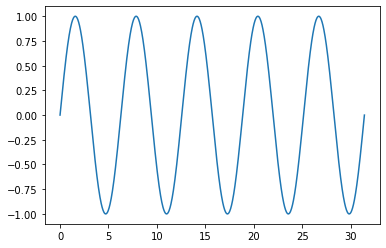

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0, 10*np.pi, 1000)
y = np.sin(x)
plt.plot(x, y)

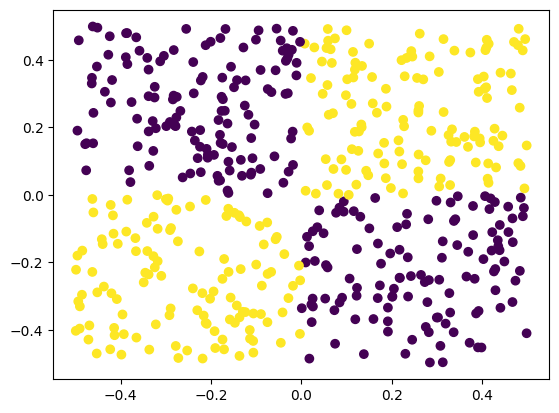

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L = np.random.random((500, 2))
X = L[:,0] - 0.5
Y = L[:,1] - 0.5
COLORS = np.sign(X * Y)
plt.scatter(X, Y, c=COLORS)

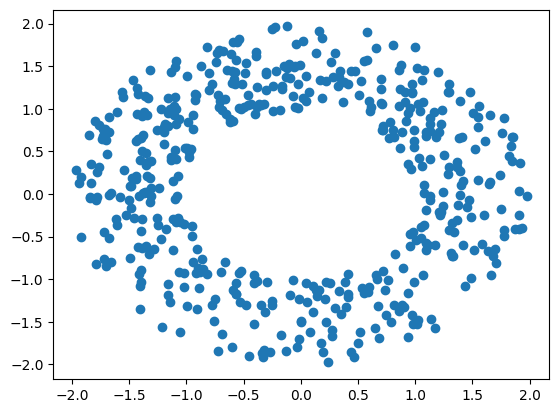

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

L = np.random.random((500, 2))
D = L[:,0] + 1
A = L[:,1] * np.pi * 2
X = D * np.cos(A)
Y = D * np.sin(A)
plt.scatter(X, Y)

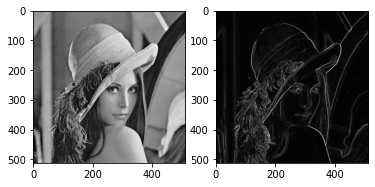

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.signal import convolve2d

im = Image.open('lena.png')
gray = np.mean(im, axis=2)

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')

#gx = hx * gray
hx = np.array([
  [1, 0,  -1],
  [2, 0, -2],
  [1, 0,  -1]])

gradx = convolve2d(gray, hx, boundary='symm', mode='same')

##plt.subplot(1,4,2)
##plt.imshow(gradx, cmap='gray');

#gy = hy * gray
hy = np.array([
  [1, 2,  1],
  [0, 0, 0],
  [-1, -2, -1]])
grady = convolve2d(gray, hy, boundary='symm', mode='same')

##plt.subplot(1,4,3)
##plt.imshow(grady, cmap='gray');

g = np.sqrt(gradx ** 2 + grady ** 2)
plt.subplot(1,2,2)
plt.imshow(g, cmap='gray');


Загрузить CSV-файлы с локального диска можно используя следующий код:

In [ ]:
from google.colab import files

# Загрузка файла
uploaded = files.upload()

# Выводим названия загруженных файлов
for filename in uploaded.keys():
    print(f'Файл загружен: {filename}')

Saving NOTES.CSV to NOTES.CSV
Файл загружен: NOTES.CSV


Вывод графика по вычисленным значениям:


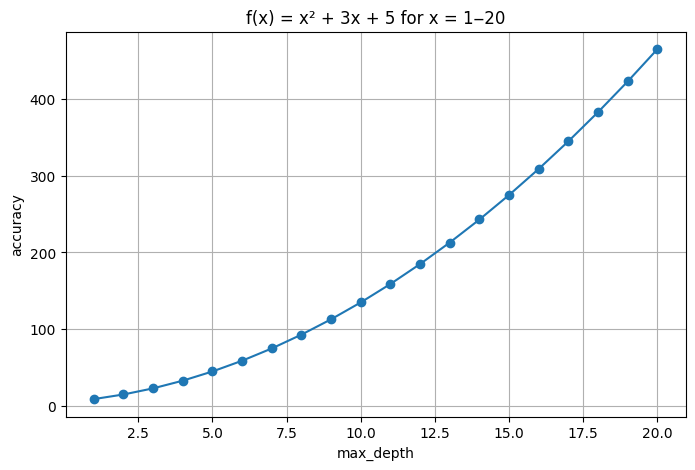

In [ ]:
import matplotlib.pyplot as plt

# Example function: f(x) = x**2 + 3*x + 5
def f(x):
    return x**2 + 3*x + 5

# Generate values 1 through 20
x_vals = list(range(1, 21))
y_vals = [f(x) for x in x_vals]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x_vals, y_vals, marker='o', linestyle='-')
plt.title('f(x) = x² + 3x + 5 for x = 1‒20')
plt.xlabel('max_depth')
plt.ylabel('accuracy')
plt.grid(True)
plt.show()


roles
1     1
2     9
3    28
4    38
5    33
6     8
Name: count, dtype: int64


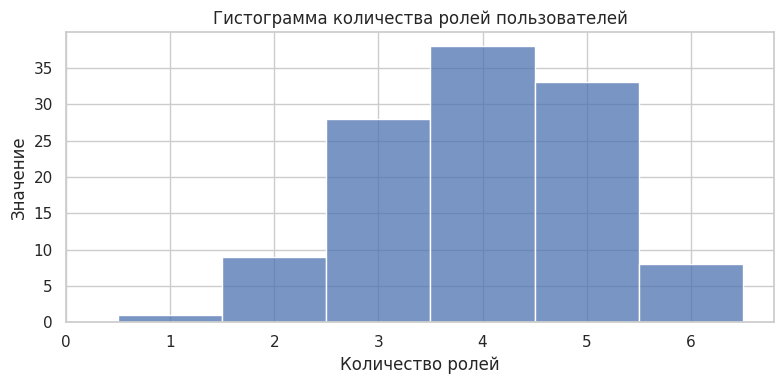

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#from google.colab import files

# Загрузка файла
#uploaded = files.upload()

df = pd.read_csv('dota_hero_stats.csv')
#print(df.head())

import ast
import numpy as np

# Пример:
# df = pd.DataFrame({'roles': ["['Carry', 'Escape', 'Nuker']", "['Support']", np.nan, "[]", ['Carry', 'Support']]})

def parse_roles(x):
    # Строка: пытаемся распарсить литерал Python
    try:
        parsed = ast.literal_eval(x)
        if isinstance(parsed, (list, tuple, set)):
            return list(parsed)
    except Exception:
        return []
    return []

#считаем длину
lengths = df['roles'].apply(lambda x: len(parse_roles(x)))

# Настройка стиля
sns.set(style="whitegrid")

# Построение гистограммы частот длин
plt.figure(figsize=(8, 4))
sns.histplot(lengths, bins=range(0, max(lengths)+2), discrete=True)
plt.xlabel("Количество ролей")
plt.ylabel("Значение")
plt.title("Гистограмма количества ролей пользователей")
plt.xticks(range(0, max(lengths)+1))
plt.tight_layout()
plt.show()